In [16]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

# graph edges
EDGES = [
    (0,1), (0,2),                     # nose -> eyes
    (3,4),       # shoulders
    (3,5), (5,7), (7,9),       # left arm
    (4,6), (6,8), (8,10),      # right arm
    (13,14),               # hips
    (13,15), (15,17),         # left leg
    (14,16), (16,18),         # right leg
    (19,21), (20,22)                   # feet
]


In [68]:
import numpy as np

def normalize_pose(points):
    """
    points: np.array shape (23, 2)
    """

    pts = points.copy().astype(float)

    mean_x = np.nanmean(pts[:,0])
    mean_y = np.nanmean(pts[:,1])
    pts[:,0] = np.nan_to_num(pts[:,0], nan=mean_x)
    pts[:,1] = np.nan_to_num(pts[:,1], nan=mean_y)



    # centre
    left_hip = pts[11]
    right_hip = pts[12]
    root = (left_hip + right_hip) / 2
    pts -= root

    # scale
    left_sh = pts[3]
    right_sh = pts[4]
    shoulder_dist = np.linalg.norm(left_sh - right_sh)

    if shoulder_dist < 1e-6:
        shoulder_dist = 1e-6

    pts /= shoulder_dist

    # orientation
    dx = right_sh[0] - left_sh[0]
    dy = right_sh[1] - left_sh[1]
    theta = np.arctan2(dy, dx)

    R = np.array([
        [ np.cos(theta),  np.sin(theta)],
        [-np.sin(theta),  np.cos(theta)]
    ])

    pts = pts @ R.T

    return pts

def angle(a, b, c):
    v1 = a - b
    v2 = c - b
    cosang = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-6)
    return np.arccos(np.clip(cosang, -1, 1))

In [69]:
def build_node_features(norm_pose):
    feats = []

    for i in range(len(norm_pose)):
        x, y = norm_pose[i]

        parent = None
        for (a,b) in EDGES:
            if b == i:
                parent = a
                break

        if parent is not None:
            rel = norm_pose[i] - norm_pose[parent]
            dist = np.linalg.norm(rel)
        else:
            rel = np.zeros(2)
            dist = 0.0

        ang = 0.0
        if i in [5,6,13,14]: 
            if i == 5: ang = angle(norm_pose[3], norm_pose[5], norm_pose[7])
            if i == 6: ang = angle(norm_pose[4], norm_pose[6], norm_pose[8])
            if i == 13: ang = angle(norm_pose[11], norm_pose[13], norm_pose[15])
            if i == 14: ang = angle(norm_pose[12], norm_pose[14], norm_pose[16])

        feats.append([x, y, rel[0], rel[1], dist, ang])

    return np.array(feats)

def build_edge_features(norm_pose):
    feats = []
    for (i,j) in EDGES:
        rel = norm_pose[j] - norm_pose[i]
        dist = np.linalg.norm(rel)
        feats.append([rel[0], rel[1], dist])
    return np.array(feats)


In [70]:
import matplotlib.pyplot as plt

def plot_pose(points, edges, title="Pose"):
    plt.figure(figsize=(5,5))
    for (i,j) in edges:
        if not np.any(np.isnan(points[i])) and not np.any(np.isnan(points[j])):
            plt.plot([points[i,0], points[j,0]],
                     [points[i,1], points[j,1]], 'k-', linewidth=2)

    plt.scatter(points[:,0], points[:,1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('equal')
    plt.show()


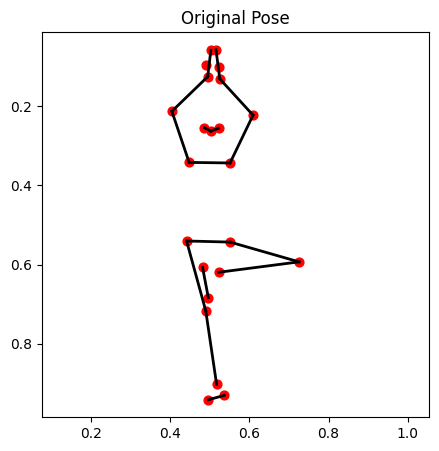

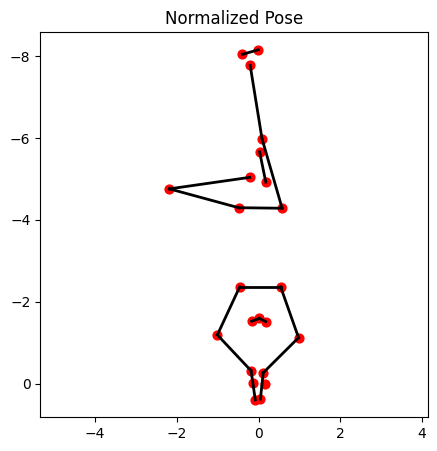

In [71]:

example_pose = np.array([
      [
        0.5024232633279483,
        0.2625
      ],
      [
        0.5218093699515347,
        0.25555555555555554
      ],
      [
        0.4862681744749596,
        0.25416666666666665
      ],
      [
        0.5508885298869144,
        0.34305555555555556
      ],
      [
        0.44749596122778673,
        0.3416666666666667
      ],
      [
        0.6090468497576736,
        0.2222222222222222
      ],
      [
        0.40387722132471726,
        0.2125
      ],
      [
        0.5250403877221325,
        0.13055555555555556
      ],
      [
        0.49434571890145396,
        0.125
      ],
      [
        0.5153473344103393,
        0.05694444444444444
      ],
      [
        0.5024232633279483,
        0.058333333333333334
      ],
      [
        0.5218093699515347,
        0.1
      ],
      [
        0.4911147011308562,
        0.09583333333333334
      ],
      [
        0.5508885298869144,
        0.5430555555555555
      ],
      [
        0.4410339256865913,
        0.5402777777777777
      ],
      [
        0.7253634894991923,
        0.5930555555555556
      ],
      [
        0.4894991922455573,
        0.7166666666666667
      ],
      [
        0.5218093699515347,
        0.6194444444444445
      ],
      [
        0.5169628432956381,
        0.9027777777777778
      ],
      [
        0.481421647819063,
        0.6069444444444444
      ],
      [
        0.5363489499192245,
        0.9305555555555556
      ],
      [
        0.49596122778675283,
        0.6833333333333333
      ],
      [
        0.49596122778675283,
        0.9416666666666667
      ]
    ])
  

# визуализация исходной позы
plot_pose(example_pose, EDGES, title="Original Pose")

# нормализация
norm_pose = normalize_pose(example_pose)

# визуализация нормализованной позы
plot_pose(norm_pose, EDGES, title="Normalized Pose")


In [ ]:
import pandas as pd



def process_csv_for_gcn(csv_path, output_npz="gcn_dataset_test.npz"):
    df = pd.read_csv(csv_path)

    node_features = []
    edge_features = []
    labels = []
    img_names = []

    for idx, row in df.iterrows():
        pts = []
        for name in KEYPOINT_NAMES:
            pts.append([row[f"{name}_x"], row[f"{name}_y"]])
        pts = np.array(pts, dtype=float)

        norm_pts = normalize_pose(pts)
        img_names.append(row["img_name"])

        nf = build_node_features(norm_pts)
        ef = build_edge_features(norm_pts)

        node_features.append(nf)
        edge_features.append(ef)
        labels.append(row["class"])

    np.savez(output_npz,
             node_features=np.array(node_features),
             edge_features=np.array(edge_features),
             labels=np.array(labels),
             edges=np.array(EDGES), img_names=np.array(img_names))

    print(f"Saved GCN dataset to {output_npz}")

    return node_features, edge_features, labels


In [72]:
process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\test_data.csv", output_npz="gcn_dataset_test.npz")

process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\train_data.csv", output_npz="gcn_dataset_train.npz")

process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\valid_data.csv", output_npz="gcn_dataset_valid.npz")

Saved GCN dataset to gcn_dataset_test.npz
Saved GCN dataset to gcn_dataset_train.npz
Saved GCN dataset to gcn_dataset_valid.npz


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_45712\3550138398.py:10: RuntimeWarning: Mean of empty slice
  mean_x = np.nanmean(pts[:,0])
C:\Users\Ульяна\AppData\Local\Temp\ipykernel_45712\3550138398.py:11: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(pts[:,1])


([array([[ 1.76760114e-02, -1.59206687e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [-1.68888074e-01, -1.52239493e+00, -1.86564086e-01,
           6.96719438e-02,  1.99149034e-01,  0.00000000e+00],
         [ 1.74980325e-01, -1.51358101e+00,  1.57304313e-01,
           7.84858644e-02,  1.75797263e-01,  0.00000000e+00],
         [-4.61453617e-01, -2.36475391e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 5.38546383e-01, -2.36475391e+00,  1.00000000e+00,
           4.44089210e-16,  1.00000000e+00,  0.00000000e+00],
         [-1.00815583e+00, -1.18872508e+00, -5.46702217e-01,
           1.17602883e+00,  1.29689133e+00,  1.95118719e+00],
         [ 9.77124071e-01, -1.12136154e+00,  4.38577688e-01,
           1.24339237e+00,  1.31847449e+00,  2.01384631e+00],
         [-1.83894886e-01, -3.13208964e-01,  8.24260948e-01,
           8.75516113e-01,  1.20247020e+00,  0.00000000e+00],
         [ 1.136

In [73]:
data = np.load("gcn_dataset_valid.npz", allow_pickle=True)

node_features = data["node_features"]
edge_features = data["edge_features"]
edges = data["edges"]
labels = data["labels"]


In [74]:
print(node_features.shape)
print(edge_features.shape)
print(edges.shape)
print(labels.shape)


(203, 23, 6)
(203, 16, 3)
(16, 2)
(203,)


In [81]:
train = np.load("gcn_dataset_train.npz", allow_pickle=True)
valid = np.load("gcn_dataset_valid.npz", allow_pickle=True)
test  = np.load("gcn_dataset_test.npz", allow_pickle=True)


labels = train["labels"]

print("Уникальные классы:", np.unique(labels))
print("Количество классов:", len(np.unique(labels)))


Уникальные классы: [0 1 2 3 4 5 6]
Количество классов: 7


In [82]:
from torch_geometric.data import Dataset
from torch_geometric.data import Data
import torch

class YogaGCNDataset(Dataset):
    def __init__(self, npz_path):
        super().__init__()
        data = np.load(npz_path, allow_pickle=True)
        self.node_features = data["node_features"]
        self.edge_features = data["edge_features"]
        self.edges = torch.tensor(data["edges"], dtype=torch.long).t().contiguous()
        self.labels = data["labels"]

    def len(self):
        return len(self.labels)

    def get(self, idx):
        x = torch.tensor(self.node_features[idx], dtype=torch.float)
        edge_attr = torch.tensor(self.edge_features[idx], dtype=torch.float)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        return Data(
            x=x,
            edge_index=self.edges,
            edge_attr=edge_attr,
            y=y
        )

from torch_geometric.loader import DataLoader

train_ds = YogaGCNDataset("gcn_dataset_train.npz")
valid_ds = YogaGCNDataset("gcn_dataset_valid.npz")
test_ds  = YogaGCNDataset("gcn_dataset_test.npz")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


In [84]:
print("\nnode_features has NaN:", np.isnan(train["node_features"]).any())
print("edge_features has NaN:", np.isnan(train["edge_features"]).any())
print("labels:", np.unique(train["labels"]))

print("\nnode_features has NaN:", np.isnan(valid["node_features"]).any())
print("edge_features has NaN:", np.isnan(valid["edge_features"]).any())
print("labels:", np.unique(valid["labels"]))

print("\nnode_features has NaN:", np.isnan(test["node_features"]).any())
print("edge_features has NaN:", np.isnan(test["edge_features"]).any())
print("labels:", np.unique(test["labels"]))



node_features has NaN: False
edge_features has NaN: False
labels: [0 1 2 3 4 5 6]

node_features has NaN: False
edge_features has NaN: False
labels: [0 1 2 3 4 5 6]

node_features has NaN: False
edge_features has NaN: False
labels: [0 1 2 3 4 5 6]


In [86]:

node = valid["node_features"]
edge = valid["edge_features"]

bad_idx = np.unique(np.where(np.isnan(node))[0])
bad_idx2 = np.unique(np.where(np.isnan(edge))[0])

print(np.unique(np.concatenate([bad_idx, bad_idx2])))


[]


In [80]:
good_mask = ~np.isnan(node).any(axis=(1,2))

node_fixed = node[good_mask]
edge_fixed = edge[good_mask]
labels_fixed = valid["labels"][good_mask]

np.savez("gcn_dataset_valid.npz",
         node_features=node_fixed,
         edge_features=edge_fixed,
         edges=valid["edges"],
         labels=labels_fixed)


In [83]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F


class YogaGCN(nn.Module):
    def __init__(self, in_channels, edge_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 64)
        self.conv2 = GCNConv(64, 64)
        self.lin1 = nn.Linear(64, 32)
        self.lin2 = nn.Linear(32, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = self.lin1(x).relu()
        return self.lin2(x)


model = YogaGCN(in_channels=node_features.shape[-1],
                edge_dim=edge_features.shape[-1],
                num_classes=len(np.unique(labels)))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()

    print("epoch", epoch, "loss", loss.item())


epoch 0 loss 1.6717712879180908
epoch 1 loss 1.5893715620040894
epoch 2 loss 1.5746784210205078
epoch 3 loss 1.637413501739502
epoch 4 loss 1.8650195598602295
epoch 5 loss 1.3919517993927002
epoch 6 loss 1.4863590002059937
epoch 7 loss 1.0028241872787476
epoch 8 loss 1.1792526245117188
epoch 9 loss 1.015175700187683
epoch 10 loss 1.2815402746200562
epoch 11 loss 1.3418588638305664
epoch 12 loss 0.8437326550483704
epoch 13 loss 1.075912356376648
epoch 14 loss 1.339560627937317
epoch 15 loss 1.20670485496521
epoch 16 loss 0.9954571723937988
epoch 17 loss 1.092291235923767
epoch 18 loss 1.2799620628356934
epoch 19 loss 0.9729436635971069
epoch 20 loss 0.6770215630531311
epoch 21 loss 0.9717642068862915
epoch 22 loss 0.6822405457496643
epoch 23 loss 1.253604769706726
epoch 24 loss 0.6675011515617371
epoch 25 loss 0.8194665908813477
epoch 26 loss 0.7151722311973572
epoch 27 loss 0.6708916425704956
epoch 28 loss 0.8886847496032715
epoch 29 loss 0.7159760594367981
epoch 30 loss 0.813831448554

In [87]:
model.eval()
correct = 0

for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    pred = out.argmax(dim=1)
    correct += (pred == batch.y).sum().item()

print("Accuracy:", correct / len(test_ds))


Accuracy: 0.6029411764705882


In [88]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_true = []

model.eval()
for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_true.extend(batch.y.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
print(cm)
print(classification_report(all_true, all_preds))


[[24  0  0  0  0  0  0]
 [ 0  7  3  0  0  4  0]
 [ 0  1  8  0  0  6  0]
 [16  0  0  1  0  0  4]
 [ 1  0  0  0 22  1  0]
 [ 0  8  3  0  0 14  0]
 [ 3  2  0  0  0  2  6]]
              precision    recall  f1-score   support

           0       0.55      1.00      0.71        24
           1       0.39      0.50      0.44        14
           2       0.57      0.53      0.55        15
           3       1.00      0.05      0.09        21
           4       1.00      0.92      0.96        24
           5       0.52      0.56      0.54        25
           6       0.60      0.46      0.52        13

    accuracy                           0.60       136
   macro avg       0.66      0.57      0.54       136
weighted avg       0.68      0.60      0.56       136



ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (2).

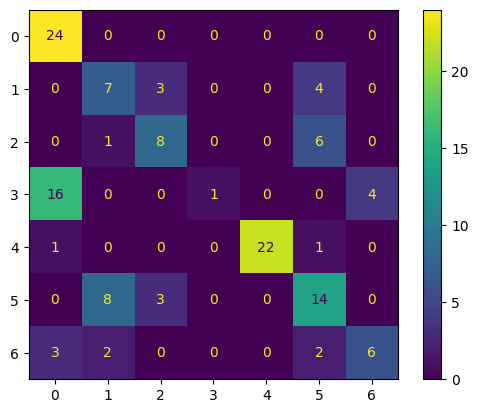

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,6])
disp.plot()
plt.show()


In [ ]:
model.eval()

mis_idx = []
mis_true = []
mis_pred = []

for batch_i, batch in enumerate(test_loader):
    out = model(batch.x, batch.edge_index, batch.batch)
    preds = out.argmax(dim=1)

    for i in range(len(preds)):
        if preds[i] != batch.y[i]:
            global_index = batch_i * test_loader.batch_size + i
            mis_idx.append(global_index)
            mis_true.append(int(batch.y[i]))
            mis_pred.append(int(preds[i]))
